<a href="https://colab.research.google.com/github/hifsakazmi/cross-dataset-stress-detection/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Overview

## Imports

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

# Escape to a known-good directory before any rmtree
os.chdir('/content')

repo_dir = '/content/cross-dataset-stress-detection'
if os.path.exists(repo_dir):
    shutil.rmtree(repo_dir)
!git clone https://github.com/hifsakazmi/cross-dataset-stress-detection.git
%cd /content/cross-dataset-stress-detection

# Re-symlink data_extracted to Drive
DRIVE_EXTRACTED = "/content/drive/MyDrive/stress_data/extracted"
if os.path.islink("data_extracted"):
    os.unlink("data_extracted")
elif os.path.exists("data_extracted"):
    shutil.rmtree("data_extracted")
os.symlink(DRIVE_EXTRACTED, "data_extracted")

!pip install -q -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'cross-dataset-stress-detection'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 173 (delta 49), reused 131 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 317.12 KiB | 7.05 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/cross-dataset-stress-detection


## Dataset Summary Table

In [13]:
import src.eda as eda_module
importlib.reload(eda_module)
from src.eda import build_dataset_summary, summary_to_dataframe, build_characterization_table

summary = build_dataset_summary(data_root=DATA_ROOT, labels_root=LABELS_ROOT)
summary_df = summary_to_dataframe(summary)
print(f"\nFlat summary: {len(summary_df)} rows across all three datasets")
summary_df.head()

Building summary for campanella...
  Loaded subject_01: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_02: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_03: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_04: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_05: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_06: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_07: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_08: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_09: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_10: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_11: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_12: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_13: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_14: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loaded subject_15: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
  Loa

,dataset,id,nurse_id,duration_sec,stress_sec,non_stress_sec,unlabeled_sec,n_windows,stress_windows,non_stress_windows,excluded,exclude_reason,has_ACC,has_BVP,has_EDA,has_HR,has_IBI,has_TEMP
0,campanella,subject_01,None,2472.843750,1692.843750,780.0,0.0,81,57,24,False,None,True,True,True,True,True,True
1,campanella,subject_02,None,2062.546875,1282.546875,780.0,0.0,67,43,24,False,None,True,True,True,True,True,True
2,campanella,subject_03,None,2056.468750,1276.468750,780.0,0.0,67,43,24,False,None,True,True,True,True,True,True
3,campanella,subject_04,None,1990.140625,1210.140625,780.0,0.0,65,41,24,False,None,True,True,True,True,True,True
4,campanella,subject_05,None,2057.656250,1277.656250,780.0,0.0,67,43,24,False,None,True,True,True,True,True,True


In [14]:
table = build_characterization_table(summary)
table_display = table.round(1)
print("Dataset characterization:")
display(table_display)

RESULTS_DIR = Path("/content/drive/MyDrive/stress_data/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

table.to_csv(RESULTS_DIR / "dataset_characterization.csv")
table_display.to_latex(
    RESULTS_DIR / "dataset_characterization.tex",
    float_format="%.1f",
    caption="Dataset characterization across the three E4 datasets.",
    label="tab:dataset_characterization",
)

Dataset characterization:


,n_subjects_kept,n_subjects_excluded,duration_min_mean,duration_min_std,duration_min_min,duration_min_max,stress_min_mean,non_stress_min_mean,unlabeled_pct_mean,n_windows_total,n_stress_windows,n_non_stress_windows,stress_to_non_stress_ratio
dataset,,,,,,,,,,,,,
campanella,26,3,36.2,3.2,32.3,43.4,23.2,13.0,0.0,1844,1220,624,2.0
wesad,15,0,116.9,10.1,101.4,135.7,11.1,19.6,73.6,919,332,587,0.6
nurse,34,575,238.3,175.5,25.4,763.7,19.7,5.6,85.4,1720,1342,378,3.6


# Graphical Analysis

## Fig 1. Visualising signals across the three datasets

One representative subject per dataset, all six E4 signals on a shared time axis,
stress / non-stress phases shaded behind the traces. The visual story:
lab protocols (Campanella, WESAD) are densely labeled with clean rectangular phases,
the nurse data is mostly unlabeled with sparse stress events floating in a long
session.

**Subjects shown:**
- Campanella: `subject_01`
- WESAD: `S2`
- Nurse: session `83_1604630543` (nurse 83, ~4.4 hr session, two labeled phases)

**Signals shown raw** — TEMP warmup spike in WESAD and BVP zero-padding in Campanella
are deliberately visible to motivate the preprocessing step.

In [15]:
# Subjects picked for the figure
CAMPANELLA_SUBJECT = "subject_01"
WESAD_SUBJECT = "S2"
NURSE_SESSION = "83_1604630543"

# Visual style: stress = red, non-stress = green, unlabeled = nothing
PHASE_COLORS = {0: "#4caf50", 1: "#e53935"}  # 0=non-stress, 1=stress
PHASE_ALPHA = 0.15

# Signal colors (one per signal, kept consistent across panels)
SIGNAL_COLORS = {
    "ACC":  "#5e35b1",
    "BVP":  "#1e88e5",
    "EDA":  "#fb8c00",
    "HR":   "#d81b60",
    "IBI":  "#00897b",
    "TEMP": "#6d4c41",
}

# Y-axis labels with units
SIGNAL_YLABELS = {
    "ACC":  "|ACC| (g)",
    "BVP":  "BVP",
    "EDA":  "EDA (\u03bcS)",
    "HR":   "HR (bpm)",
    "IBI":  "IBI (s)",
    "TEMP": "TEMP (\u00b0C)",
}

# Order the signals top-to-bottom in each panel
SIGNAL_ORDER = ["ACC", "BVP", "EDA", "HR", "IBI", "TEMP"]

In [16]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import src.data_loader as data_loader
import src.labeling as labeling
importlib.reload(data_loader)
importlib.reload(labeling)

from src.data_loader import load_subject
from src.labeling import get_campanella_labels, get_wesad_labels

DATA_ROOT = "data_extracted"
LABELS_ROOT = "labels"


### Load the three subjects and their labels

Phases come from three different sources:
- Campanella: computed from protocol timing
- WESAD: pre-extracted CSV in `labels/wesad/`
- Nurse: pre-extracted CSV in `labels/nurse/`

In [17]:
def load_nurse_labels(session_id, labels_root=LABELS_ROOT):
    """Load pre-extracted nurse phases as (start_sec, end_sec, label) tuples."""
    df = pd.read_csv(Path(labels_root) / "nurse" / f"{session_id}.csv")
    return list(df.itertuples(index=False, name=None))


def get_duration_sec(signals):
    """Recording duration in seconds, computed from the shortest signal."""
    return min(
        (sig.index[-1] - sig.index[0]).total_seconds()
        for sig in signals.values() if len(sig) > 0
    )


# Campanella
camp_signals, _ = load_subject("campanella", CAMPANELLA_SUBJECT, data_root=DATA_ROOT)
camp_duration = get_duration_sec(camp_signals)
camp_phases = get_campanella_labels(camp_duration)
print(f"Campanella {CAMPANELLA_SUBJECT}: {camp_duration/60:.1f} min, "
      f"{len(camp_phases)} phases")

# WESAD
wesad_signals, _ = load_subject("wesad", WESAD_SUBJECT, data_root=DATA_ROOT)
wesad_duration = get_duration_sec(wesad_signals)
wesad_phases = get_wesad_labels(WESAD_SUBJECT)
print(f"WESAD {WESAD_SUBJECT}: {wesad_duration/60:.1f} min, "
      f"{len(wesad_phases)} phases")

# Nurse
nurse_signals, _ = load_subject("nurse", NURSE_SESSION, data_root=DATA_ROOT)
nurse_duration = get_duration_sec(nurse_signals)
nurse_phases = load_nurse_labels(NURSE_SESSION)
print(f"Nurse {NURSE_SESSION}: {nurse_duration/60:.1f} min, "
      f"{len(nurse_phases)} phases")

  Loaded subject_01: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
Campanella subject_01: 41.2 min, 11 phases
  Loaded S2: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
WESAD S2: 130.7 min, 2 phases
  Loaded 83_1604630543: ['ACC', 'BVP', 'EDA', 'HR', 'IBI', 'TEMP']
Nurse 83_1604630543: 266.6 min, 2 phases


### Plotting helpers

Two helpers:
- `signal_to_xy(df, signal_name)` — converts a signal DataFrame to (time_minutes, values).
  Handles ACC (3 axes → magnitude) and IBI (irregular sampling → use the offset column).
- `plot_dataset_panel(ax_row, signals, phases, duration, title)` — fills one row of
  6 subplots with shading + traces.

In [18]:
def signal_to_xy(df, signal_name):
    """
    Convert a signal DataFrame to (time_minutes_from_start, values).

    - ACC has 3 columns (x, y, z) -> return magnitude sqrt(x^2+y^2+z^2)
    - IBI is irregular -> use its time index as-is (already datetime)
    - Everything else is single-column
    """
    t0 = df.index[0]
    times_min = (df.index - t0).total_seconds() / 60

    if signal_name == "ACC":
        vals = np.sqrt((df.values.astype(float) ** 2).sum(axis=1)) / 64.0
        # E4 ACC is in 1/64 g units; divide by 64 to get g
    elif signal_name == "IBI":
        # df has columns ['offset', 'ibi'] — we want ibi as the value
        if "ibi" in df.columns:
            vals = df["ibi"].values.astype(float)
        else:
            vals = df.iloc[:, -1].values.astype(float)
    else:
        vals = df.iloc[:, 0].values.astype(float)

    return times_min.values, vals


def shade_phases(ax, phases, total_duration_sec):
    """Shade phase regions on a single axis. Times are converted to minutes."""
    for start_sec, end_sec, label in phases:
        color = PHASE_COLORS.get(label)
        if color is None:
            continue
        ax.axvspan(start_sec / 60, end_sec / 60,
                   color=color, alpha=PHASE_ALPHA, zorder=0)


def plot_dataset_panel(ax_row, signals, phases, duration_sec, dataset_title):
    """
    Fill one row of axes (6 subplots) with the 6 signals for one dataset.

    ax_row: 1D array of 6 Axes, left-to-right matches SIGNAL_ORDER
    """
    for ax, sig_name in zip(ax_row, SIGNAL_ORDER):
        if sig_name not in signals:
            ax.text(0.5, 0.5, f"{sig_name}\nnot available",
                    ha="center", va="center", transform=ax.transAxes,
                    color="grey", fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        df = signals[sig_name]
        if len(df) == 0:
            ax.text(0.5, 0.5, f"{sig_name}\nempty", ha="center", va="center",
                    transform=ax.transAxes, color="grey", fontsize=9)
            continue

        # Shade phases first (behind the trace)
        shade_phases(ax, phases, duration_sec)

        # Plot signal
        times_min, vals = signal_to_xy(df, sig_name)
        if sig_name == "IBI":
            ax.scatter(times_min, vals, s=3,
                       color=SIGNAL_COLORS[sig_name], alpha=0.6)
        else:
            ax.plot(times_min, vals,
                    color=SIGNAL_COLORS[sig_name], linewidth=0.6)

        ax.set_ylabel(SIGNAL_YLABELS[sig_name], fontsize=9)
        ax.set_xlim(0, duration_sec / 60)
        ax.tick_params(axis="both", labelsize=8)
        ax.grid(True, alpha=0.2, linewidth=0.5)

    # Dataset label on the leftmost axis
    ax_row[0].annotate(
        dataset_title,
        xy=(-0.35, 0.5), xycoords="axes fraction",
        ha="center", va="center",
        fontsize=12, fontweight="bold", rotation=90,
    )

/tmp/ipykernel_10784/1071151487.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 1, 0.95])


Saved: results/fig1_signal_panel.png and .pdf


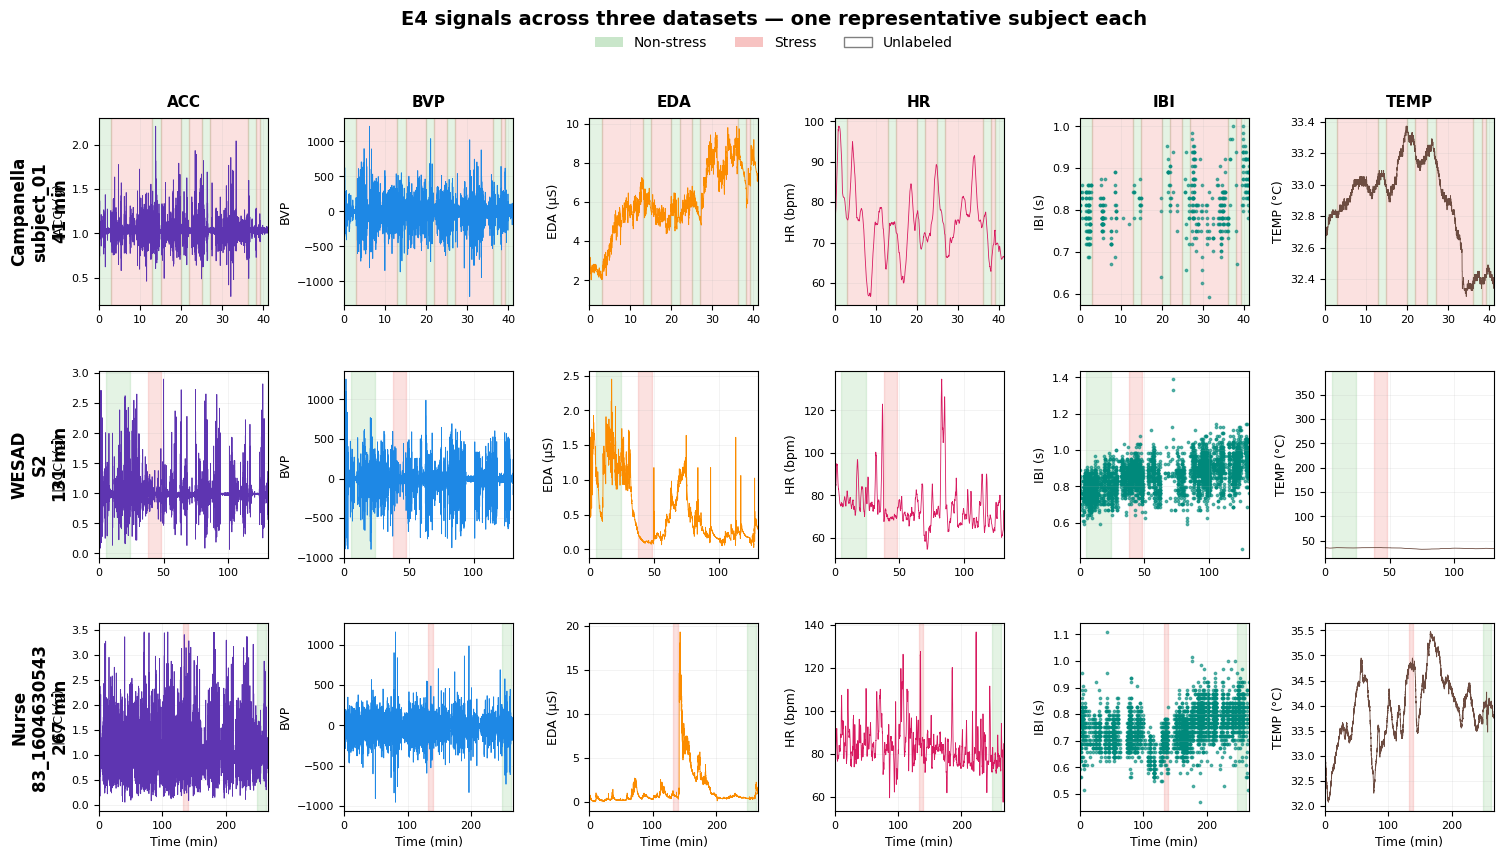

In [19]:
RESULTS_DIR = Path("/content/drive/MyDrive/stress_data/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(
    nrows=3, ncols=6,
    figsize=(18, 9),
    gridspec_kw={"hspace": 0.35, "wspace": 0.45},
)

plot_dataset_panel(
    axes[0], camp_signals, camp_phases, camp_duration,
    f"Campanella\n{CAMPANELLA_SUBJECT}\n{camp_duration/60:.0f} min",
)
plot_dataset_panel(
    axes[1], wesad_signals, wesad_phases, wesad_duration,
    f"WESAD\n{WESAD_SUBJECT}\n{wesad_duration/60:.0f} min",
)
plot_dataset_panel(
    axes[2], nurse_signals, nurse_phases, nurse_duration,
    f"Nurse\n{NURSE_SESSION}\n{nurse_duration/60:.0f} min",
)

# Column titles: signal names across the top
for ax, sig_name in zip(axes[0], SIGNAL_ORDER):
    ax.set_title(sig_name, fontsize=11, fontweight="bold", pad=8)

# X-axis label only on the bottom row
for ax in axes[2]:
    ax.set_xlabel("Time (min)", fontsize=9)

# Legend for phase colors
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=PHASE_COLORS[0], alpha=PHASE_ALPHA * 2,
          label="Non-stress"),
    Patch(facecolor=PHASE_COLORS[1], alpha=PHASE_ALPHA * 2,
          label="Stress"),
    Patch(facecolor="white", edgecolor="grey",
          label="Unlabeled"),
]
fig.legend(handles=legend_handles, loc="upper center",
           bbox_to_anchor=(0.5, 0.985), ncol=3, fontsize=10,
           frameon=False)

fig.suptitle(
    "E4 signals across three datasets — one representative subject each",
    fontsize=14, fontweight="bold", y=1.00,
)

plt.tight_layout(rect=[0.02, 0, 1, 0.95])

# Save as both PNG (for slides) and PDF (for the paper).
Path("results").mkdir(exist_ok=True)
fig.savefig(RESULTS_DIR / "fig1_signal_panel.png", dpi=200, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "fig1_signal_panel.pdf", bbox_inches="tight")
print("Saved: results/fig1_signal_panel.png and .pdf")

plt.show()

## Notes

**Campanella (top row)** — Clean alternating rest/task pattern. The BVP panel
starts with a brief flat segment (device warmup, zero-padded), HR ramps from 0
for the same reason, and the protocol's rectangular phases match the signal
responses visibly (HR climbs during task periods, EDA shows arousal spikes).

**WESAD (middle row)** — Two labeled phases: baseline and stress. The TEMP
panel shows the warmup spike near t=0 noted in the project context. EDA shows
the clearest contrast — much higher during the stress phase. Long unlabeled
regions correspond to amusement / meditation conditions that we dropped to
match the binary protocol of the other two datasets.

**Nurse (bottom row)** — The story. ~4 hours of recording, two small labeled
blocks (one stress around 130 min, one non-stress around 250 min) floating in
a sea of unlabeled time. This is what real-world stress labeling looks like
compared to a lab protocol.

## Fig 2. Window-level class balance

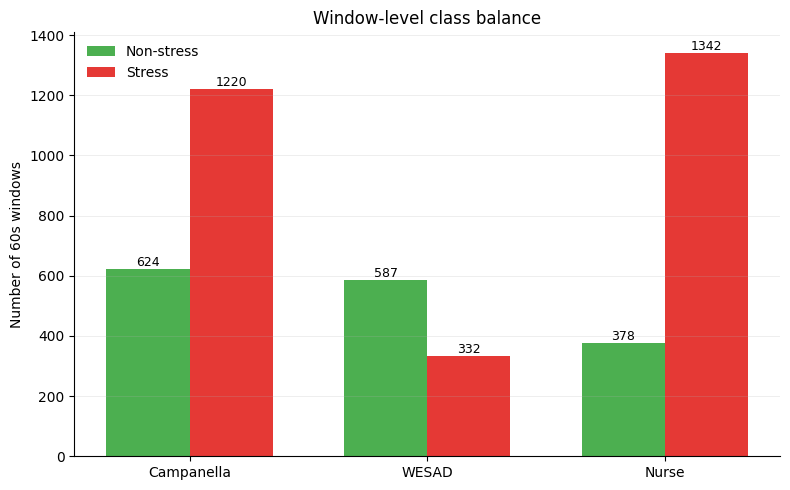

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

datasets = ["campanella", "wesad", "nurse"]
labels_pretty = ["Campanella", "WESAD", "Nurse"]

stress_counts = [
    sum(r["stress_windows"] for r in summary[d] if not r["excluded"])
    for d in datasets
]
non_stress_counts = [
    sum(r["non_stress_windows"] for r in summary[d] if not r["excluded"])
    for d in datasets
]

x = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(x - width/2, non_stress_counts, width,
               label="Non-stress", color=PHASE_COLORS[0])
bars2 = ax.bar(x + width/2, stress_counts, width,
               label="Stress", color=PHASE_COLORS[1])

# Counts on top of bars
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h, f"{int(h)}",
                ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels_pretty)
ax.set_ylabel("Number of 60s windows")
ax.set_title("Window-level class balance")
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.3, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig2_window_class_balance.png", dpi=200, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "fig2_window_class_balance.pdf", bbox_inches="tight")
plt.show()

## Fig 3. Recording duration distribution

For Campanella and WESAD, one point per subject. For Nurse, one point per
session (sessions vary 25 min to 12 hr).

/tmp/ipykernel_10784/1975843257.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


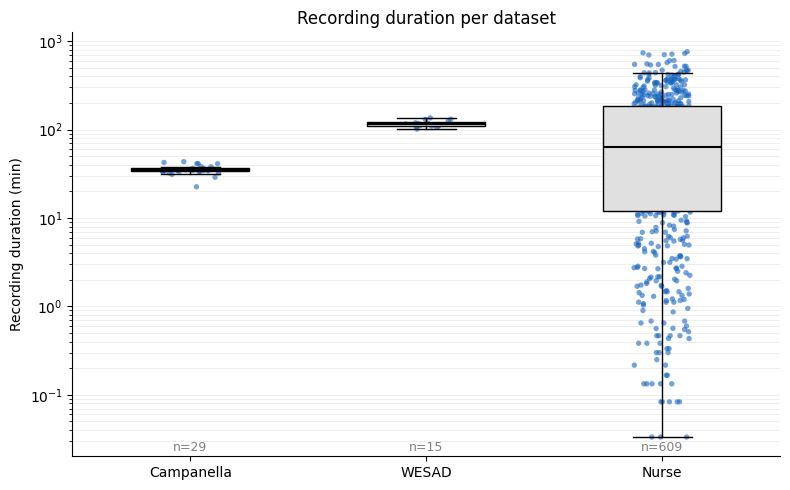

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

durations_per_dataset = []
for d in datasets:
    # Include excluded ones too — duration is real even if labels aren't usable
    durs = [r["duration_sec"] / 60 for r in summary[d] if r["duration_sec"] > 0]
    durations_per_dataset.append(durs)

bp = ax.boxplot(
    durations_per_dataset,
    labels=labels_pretty,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.5),
    boxprops=dict(facecolor="#e0e0e0", edgecolor="black"),
)

# Strip plot overlay (jittered points)
rng = np.random.default_rng(0)
for i, durs in enumerate(durations_per_dataset, start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(durs))
    ax.scatter(np.full(len(durs), i) + jitter, durs,
               s=15, alpha=0.6, color="#1565c0", edgecolor="none")

ax.set_ylabel("Recording duration (min)")
ax.set_title("Recording duration per dataset")
ax.set_yscale("log")  # huge spread for nurse — log makes all three readable
ax.grid(True, axis="y", which="both", alpha=0.3, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Annotate counts under labels
for i, durs in enumerate(durations_per_dataset, start=1):
    ax.text(i, ax.get_ylim()[0] * 1.05, f"n={len(durs)}",
            ha="center", va="bottom", fontsize=9, color="grey")

plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig3_duration_distribution.png", dpi=200, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "fig3_duration_distribution.pdf", bbox_inches="tight")
plt.show()

## Fig 5: Labeled vs unlabeled time per dataset

The fraction of each dataset's recording time that we can actually use. Here we can observe that "real-world data (Nurses Dataset) is sparsely labeled".

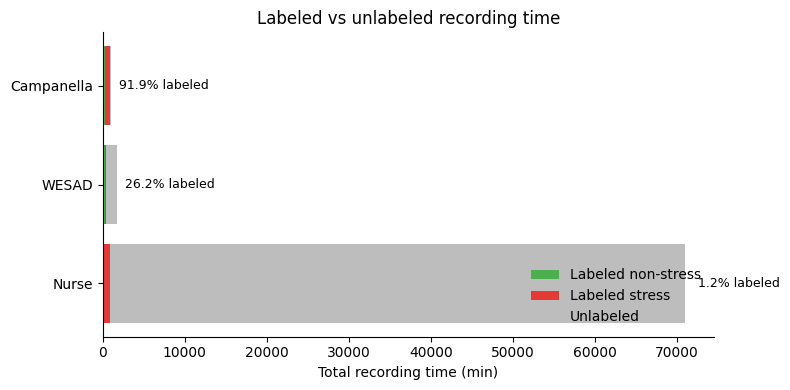

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

stress_totals = [
    sum(r["stress_sec"] for r in summary[d] if not r["excluded"]) / 60
    for d in datasets
]
non_stress_totals = [
    sum(r["non_stress_sec"] for r in summary[d] if not r["excluded"]) / 60
    for d in datasets
]
# For "unlabeled", count duration from ALL records (including ones excluded only
# because they have no labels — they're still recorded time)
total_durations = [
    sum(r["duration_sec"] for r in summary[d]) / 60
    for d in datasets
]
unlabeled_totals = [
    total - stress - non_stress
    for total, stress, non_stress in zip(total_durations, stress_totals, non_stress_totals)
]

y = np.arange(len(datasets))
ax.barh(y, non_stress_totals, color=PHASE_COLORS[0], label="Labeled non-stress")
ax.barh(y, stress_totals, left=non_stress_totals,
        color=PHASE_COLORS[1], label="Labeled stress")
ax.barh(y, unlabeled_totals,
        left=[a + b for a, b in zip(non_stress_totals, stress_totals)],
        color="#bdbdbd", label="Unlabeled")

# Percentages as overlay labels
for i, (ns, s, u) in enumerate(zip(non_stress_totals, stress_totals, unlabeled_totals)):
    total = ns + s + u
    if total == 0:
        continue
    ax.text(total + total * 0.01, i,
            f"  {(ns+s)/total*100:.1f}% labeled",
            va="center", fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(labels_pretty)
ax.invert_yaxis()
ax.set_xlabel("Total recording time (min)")
ax.set_title("Labeled vs unlabeled recording time")
ax.legend(frameon=False, loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(RESULTS_DIR / "fig5_labeled_unlabeled.png", dpi=200, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "fig5_labeled_unlabeled.pdf", bbox_inches="tight")
plt.show()